In [189]:
import pandas as pd

day_0_prices = pd.read_csv("../../data/round_3/prices_round_3_day_0.csv", sep=";")
day_1_prices = pd.read_csv("../../data/round_3/prices_round_3_day_1.csv", sep=";")
day_2_prices = pd.read_csv("../../data/round_3/prices_round_3_day_2.csv", sep=";")

day_0_trades = pd.read_csv("../../data/round_3/trades_round_3_day_0.csv", sep=";")
day_1_trades = pd.read_csv("../../data/round_3/trades_round_3_day_1.csv", sep=";")
day_2_trades = pd.read_csv("../../data/round_3/trades_round_3_day_2.csv", sep=";")

day_0_prices["day"] = 0
day_1_prices["day"] = 1
day_2_prices["day"] = 2

day_0_trades["day"] = 0
day_1_trades["day"] = 1
day_2_trades["day"] = 2

all_prices = pd.concat(
    [day_0_prices, day_1_prices, day_2_prices],
    ignore_index=True
)

all_trades = pd.concat(
    [day_0_trades, day_1_trades, day_2_trades],
    ignore_index=True
)

all_prices["global_time"] = all_prices["day"] * 1_000_000 + all_prices["timestamp"]
all_trades["global_time"] = all_trades["day"] * 1_000_000 + all_trades["timestamp"]

DELTA_ONE_PRODUCTS = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
]

VOUCHERS = [
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
    "VEV_6000",
    "VEV_6500",
]

ALL_PRODUCTS = DELTA_ONE_PRODUCTS + VOUCHERS

prices_by_product = {
    product: all_prices[all_prices["product"] == product].copy()
    for product in ALL_PRODUCTS
}

trades_by_product = {
    product: all_trades[all_trades["symbol"] == product].copy()
    for product in ALL_PRODUCTS
}

hydro_prices = prices_by_product["HYDROGEL_PACK"]
fruit_prices = prices_by_product["VELVETFRUIT_EXTRACT"]

hydro_trades = trades_by_product["HYDROGEL_PACK"]
fruit_trades = trades_by_product["VELVETFRUIT_EXTRACT"]

vev_4000_prices = prices_by_product["VEV_4000"]
vev_4500_prices = prices_by_product["VEV_4500"]
vev_5000_prices = prices_by_product["VEV_5000"]
vev_5100_prices = prices_by_product["VEV_5100"]
vev_5200_prices = prices_by_product["VEV_5200"]
vev_5300_prices = prices_by_product["VEV_5300"]
vev_5400_prices = prices_by_product["VEV_5400"]
vev_5500_prices = prices_by_product["VEV_5500"]
vev_6000_prices = prices_by_product["VEV_6000"]
vev_6500_prices = prices_by_product["VEV_6500"]

vev_4000_trades = trades_by_product["VEV_4000"]
vev_4500_trades = trades_by_product["VEV_4500"]
vev_5000_trades = trades_by_product["VEV_5000"]
vev_5100_trades = trades_by_product["VEV_5100"]
vev_5200_trades = trades_by_product["VEV_5200"]
vev_5300_trades = trades_by_product["VEV_5300"]
vev_5400_trades = trades_by_product["VEV_5400"]
vev_5500_trades = trades_by_product["VEV_5500"]
vev_6000_trades = trades_by_product["VEV_6000"]
vev_6500_trades = trades_by_product["VEV_6500"]

voucher_prices = all_prices[all_prices["product"].isin(VOUCHERS)].copy()
voucher_trades = all_trades[all_trades["symbol"].isin(VOUCHERS)].copy()

voucher_prices["strike"] = voucher_prices["product"].str.replace("VEV_", "").astype(int)
voucher_trades["strike"] = voucher_trades["symbol"].str.replace("VEV_", "").astype(int)

all_prices["tte"] = 8 - all_prices["day"]
all_trades["tte"] = 8 - all_trades["day"]

voucher_prices["tte"] = 8 - voucher_prices["day"]
voucher_trades["tte"] = 8 - voucher_trades["day"]

In [190]:
hydro_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0
19,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,100
24,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,200
41,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0,300
54,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359946,2,999500,HYDROGEL_PACK,10002,11,10000.0,28.0,NaN,NaN,10018,11,10021.0,28.0,NaN,NaN,10010.0,0.0,2999500
359959,2,999600,HYDROGEL_PACK,10004,13,10001.0,30.0,NaN,NaN,10020,13,10022.0,30.0,NaN,NaN,10012.0,0.0,2999600
359964,2,999700,HYDROGEL_PACK,10004,13,10002.0,28.0,NaN,NaN,10020,13,10023.0,28.0,NaN,NaN,10012.0,0.0,2999700
359985,2,999800,HYDROGEL_PACK,10003,10,10000.0,27.0,NaN,NaN,10019,10,10021.0,27.0,NaN,NaN,10011.0,0.0,2999800


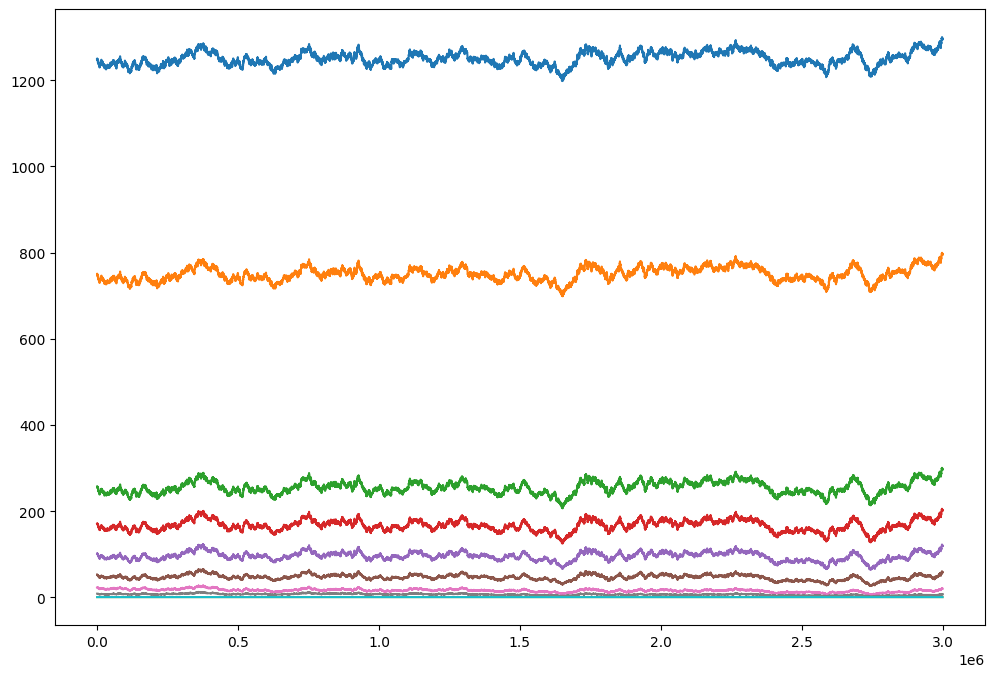

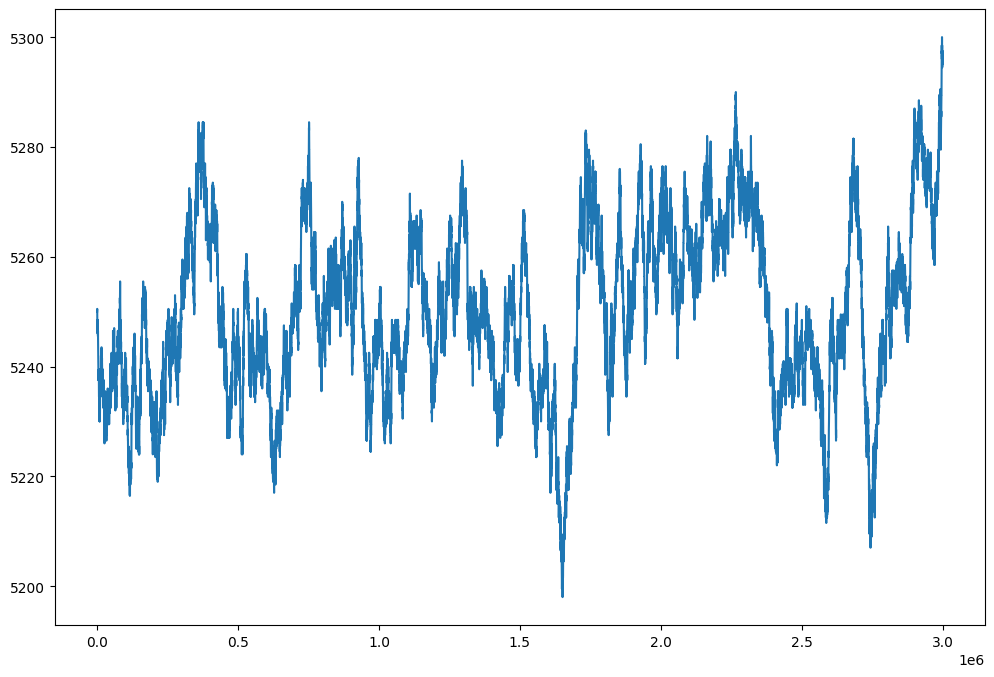

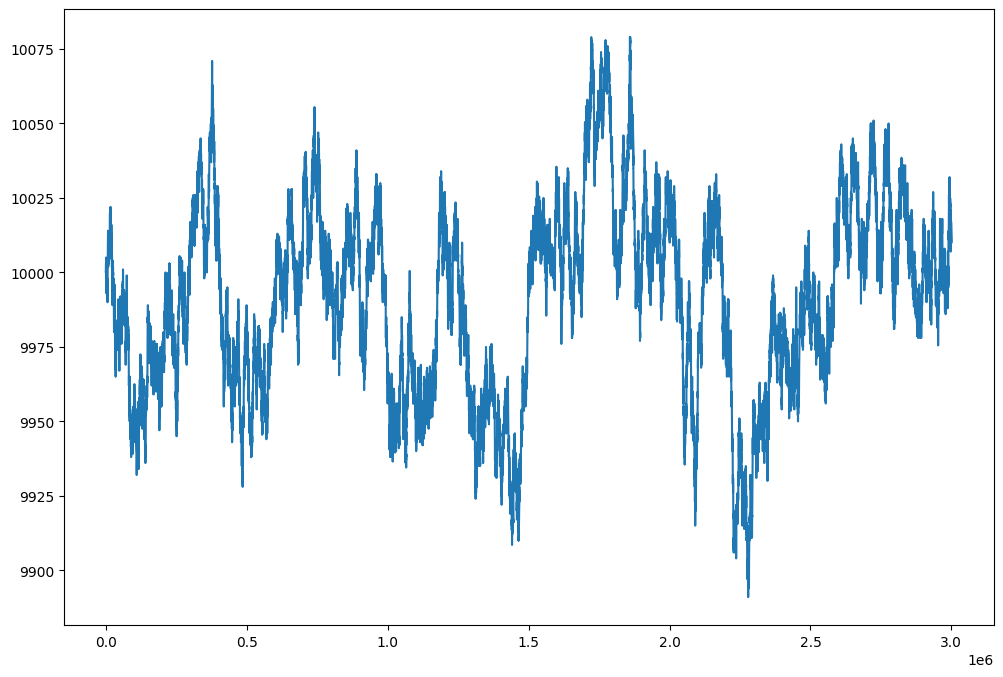

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(vev_4000_prices["global_time"], vev_4000_prices["mid_price"]) 
plt.plot(vev_4000_prices["global_time"], vev_4500_prices["mid_price"]) 
plt.plot(vev_4000_prices["global_time"], vev_5000_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_5100_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_5200_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_5300_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_5400_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_5500_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_6000_prices["mid_price"])
plt.plot(vev_4000_prices["global_time"], vev_6500_prices["mid_price"])

plt.figure(figsize=(12, 8))
plt.plot(fruit_prices["global_time"], fruit_prices["mid_price"])

plt.figure(figsize=(12, 8))
plt.plot(hydro_prices["global_time"], hydro_prices["mid_price"])

In [192]:
vev_4500_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
6,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,6,760.0,13.0,NaN,NaN,750.0,0.0,0
12,0,100,VEV_4500,743,9,741.0,13.0,NaN,NaN,759,9,761.0,13.0,NaN,NaN,751.0,0.0,100
35,0,200,VEV_4500,742,10,740.0,12.0,NaN,NaN,758,10,760.0,12.0,NaN,NaN,750.0,0.0,200
46,0,300,VEV_4500,742,11,740.0,18.0,NaN,NaN,758,11,760.0,18.0,NaN,NaN,750.0,0.0,300
53,0,400,VEV_4500,742,8,740.0,23.0,NaN,NaN,758,8,760.0,23.0,NaN,NaN,750.0,0.0,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359948,2,999500,VEV_4500,787,9,785.0,12.0,NaN,NaN,804,9,806.0,12.0,NaN,NaN,795.5,0.0,2999500
359952,2,999600,VEV_4500,788,11,786.0,16.0,NaN,NaN,805,11,807.0,16.0,NaN,NaN,796.5,0.0,2999600
359966,2,999700,VEV_4500,789,9,787.0,12.0,NaN,NaN,806,9,808.0,12.0,NaN,NaN,797.5,0.0,2999700
359978,2,999800,VEV_4500,788,7,786.0,14.0,NaN,NaN,805,7,807.0,14.0,NaN,NaN,796.5,0.0,2999800


In [193]:
vev_4000_prices = vev_4000_prices.merge(
    fruit_prices[["global_time", "mid_price"]],
    on="global_time",
    how="left"
)

vev_4000_prices.rename(columns={"mid_price_y": "s"}, inplace=True)

In [194]:
import numpy as np

fruit_prices = fruit_prices.sort_values("global_time").copy()

fruit_prices["log_return"] = np.log(
    fruit_prices["mid_price"] / fruit_prices["mid_price"].shift(1)
)

window = 50  # tune this: 25, 50, 100, 200

fruit_prices["rolling_sigma"] = (
    fruit_prices["log_return"]
    .rolling(window)
    .std()
    * np.sqrt(365)
)

In [195]:
vev_4000_prices = pd.merge_asof(
    vev_4000_prices.sort_values("global_time"),
    fruit_prices[["global_time", "rolling_sigma"]].sort_values("global_time"),
    on="global_time",
    direction="backward"
)

vev_4000_prices["sigma"] = vev_4000_prices["rolling_sigma"]

In [196]:
default_sigma = fruit_prices["log_return"].std() * np.sqrt(365)

vev_4000_prices["sigma"] = (
    vev_4000_prices["sigma"]
    .fillna(default_sigma)
    .clip(lower=0.01, upper=3.0)
)

In [197]:
vev_4000_prices["k"] = 4000
vev_4000_prices["t"] = 5
vev_4000_prices["r"] = 0
vev_4000_prices["mid_price"] = (vev_4000_prices["bid_price_1"] + 
                                vev_4000_prices["ask_price_1"]) / 2

In [198]:
from numpy import log, sqrt

vev_4000_prices["d1"] = (
    log(vev_4000_prices["s"] / vev_4000_prices["k"]) +
    (vev_4000_prices["r"] + vev_4000_prices["sigma"] / 2) * vev_4000_prices["t"]
) / (
    sqrt(vev_4000_prices["sigma"]) * sqrt(vev_4000_prices["t"])
)

vev_4000_prices["d2"] = vev_4000_prices["d1"] - sqrt(vev_4000_prices["sigma"]) * sqrt(vev_4000_prices["t"])

In [199]:
from math import erf, sqrt, log

def normal_cdf(value: float) -> float:
    return 0.5 * (1.0 + erf(value / sqrt(2.0)))


def black_scholes_call(spot: float, strike: float, tte_days: float, volatility: float) -> float:
    intrinsic = max(0.0, spot - strike)
    if spot <= 0 or strike <= 0 or tte_days <= 0 or volatility <= 0:
        return intrinsic

    tte_years = max(tte_days / 365.0, 1e-6)
    sigma_sqrt_t = volatility * sqrt(tte_years)
    if sigma_sqrt_t <= 1e-9:
        return intrinsic

    d1 = (log(vev_4000_prices["s"] / vev_4000_prices["k"]) + 
          0.5 * volatility ** 2 * vev_4000_prices["t"]) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    return max(intrinsic, spot * normal_cdf(d1) - strike * normal_cdf(d2))

In [200]:
import numpy as np
from scipy.stats import norm

def black_scholes_call_vec(spot, strike, t_days, vol):
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    t_days = np.asarray(t_days, dtype=float)
    vol = np.asarray(vol, dtype=float)

    intrinsic = np.maximum(0.0, spot - strike)

    t = np.maximum(t_days / 365.0, 1e-6)
    sigma_sqrt_t = np.maximum(vol * np.sqrt(t), 1e-9)

    d1 = (np.log(spot / strike) + 0.5 * vol**2 * t) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t

    return np.maximum(
        intrinsic,
        spot * norm.cdf(d1) - strike * norm.cdf(d2)
    )

In [201]:
vev_4000_prices["bs_call"] = black_scholes_call_vec(
    vev_4000_prices["s"],
    vev_4000_prices["k"],
    vev_4000_prices["t"],
    vev_4000_prices["sigma"]
)

In [202]:
vev_4000_prices["spread"] = vev_4000_prices["ask_price_1"] - vev_4000_prices["bid_price_1"]

In [203]:
vev_4000_prices["bs_spread"] = (vev_4000_prices["bs_call"] - 
                                vev_4000_prices["mid_price"])

In [204]:
vev_4000_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,sigma,k,t,r,mid_price,d1,d2,bs_call,spread,bs_spread
0,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,...,0.01,4000,5,0,1250.0,1.327928,1.104321,1250.0,20,0.0
1,0,100,VEV_4000,1240,11,1238.0,20.0,NaN,NaN,1261,...,0.01,4000,5,0,1250.5,1.328354,1.104747,1250.5,21,0.0
2,0,200,VEV_4000,1240,13,1237.0,21.0,NaN,NaN,1261,...,0.01,4000,5,0,1250.5,1.328354,1.104747,1250.5,21,0.0
3,0,300,VEV_4000,1240,10,1237.0,29.0,NaN,NaN,1261,...,0.01,4000,5,0,1250.5,1.328354,1.104747,1250.5,21,0.0
4,0,400,VEV_4000,1240,10,1237.0,25.0,NaN,NaN,1261,...,0.01,4000,5,0,1250.5,1.328354,1.104747,1250.5,21,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2,999500,VEV_4000,1285,9,1282.0,23.0,NaN,NaN,1307,...,0.01,4000,5,0,1296.0,1.366519,1.142913,1295.5,22,-0.5
29996,2,999600,VEV_4000,1286,12,1283.0,23.0,NaN,NaN,1308,...,0.01,4000,5,0,1297.0,1.367364,1.143757,1296.5,22,-0.5
29997,2,999700,VEV_4000,1286,8,1284.0,17.0,NaN,NaN,1308,...,0.01,4000,5,0,1297.0,1.368208,1.144601,1297.5,22,0.5
29998,2,999800,VEV_4000,1286,7,1283.0,24.0,NaN,NaN,1307,...,0.01,4000,5,0,1296.5,1.367364,1.143757,1296.5,21,0.0


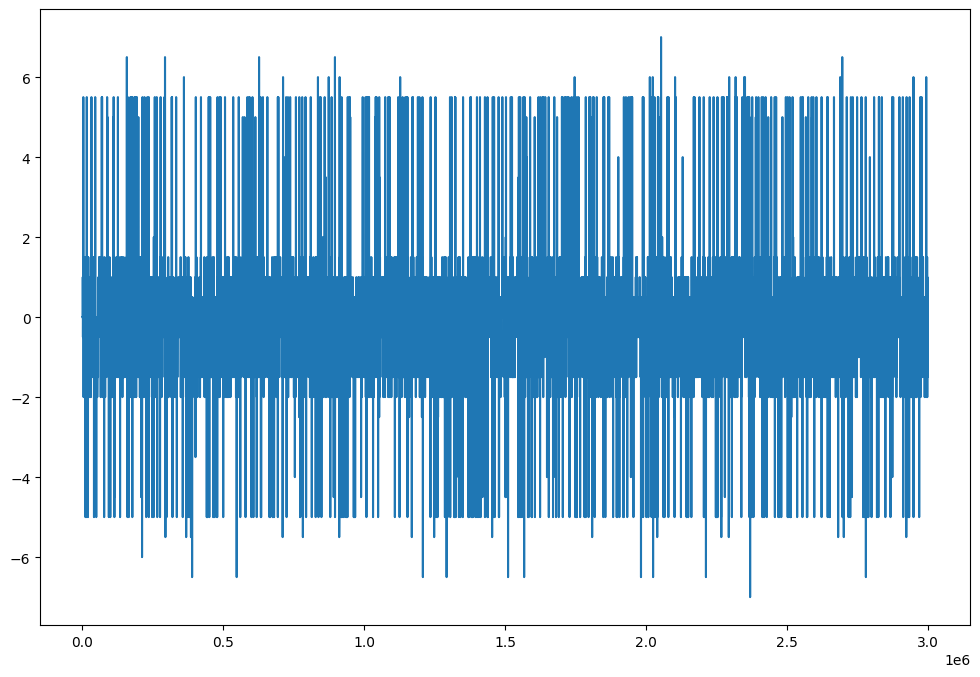

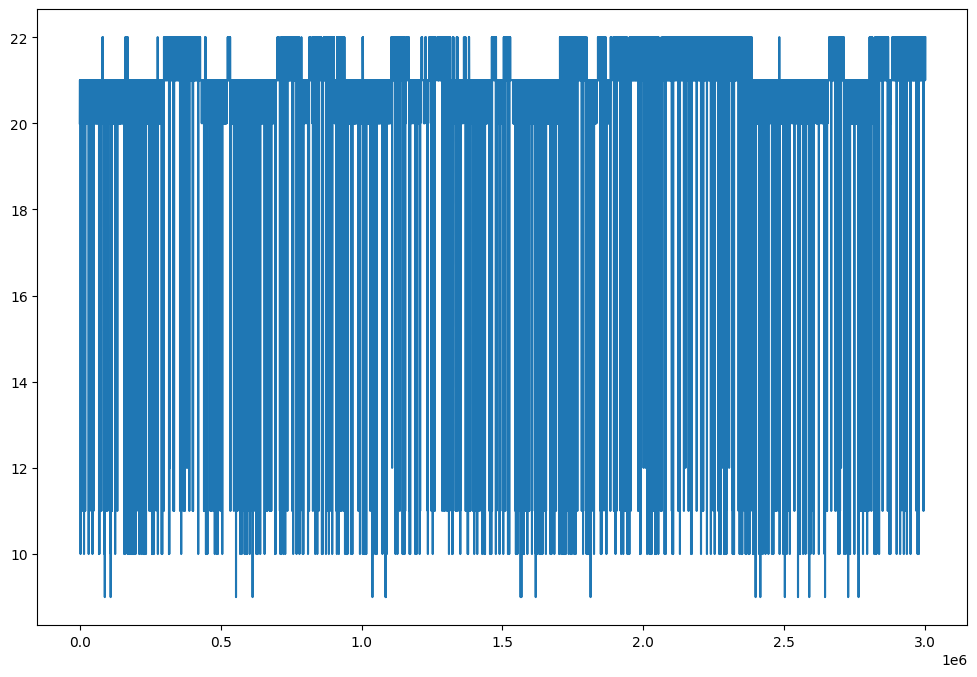

In [209]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(vev_4000_prices["global_time"], vev_4000_prices["bs_spread"])
plt.figure(figsize=(12, 8))
plt.plot(vev_4000_prices["global_time"], vev_4000_prices["spread"])

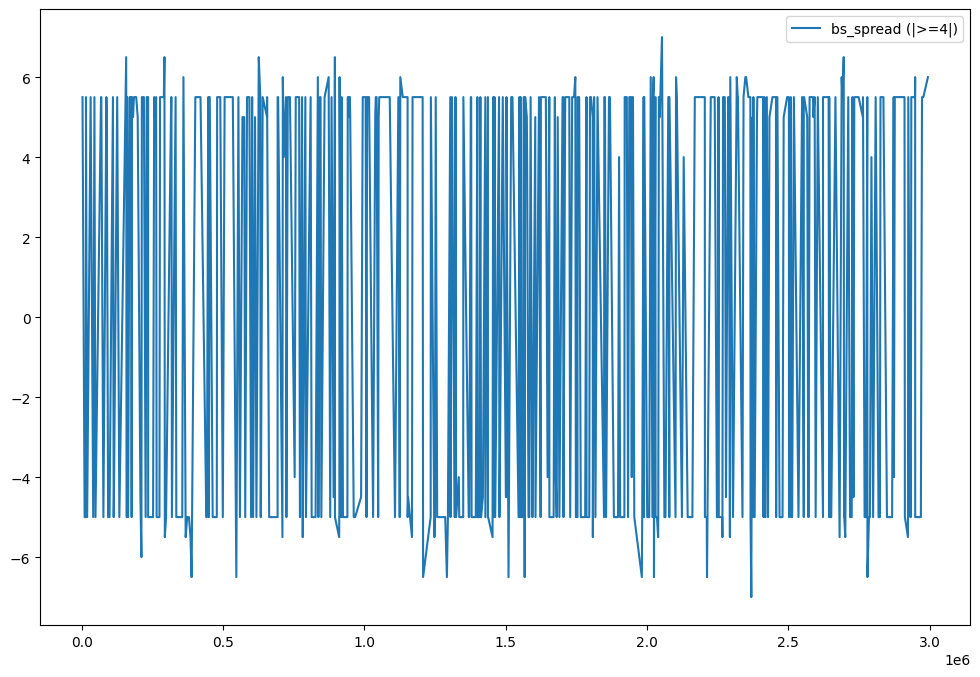

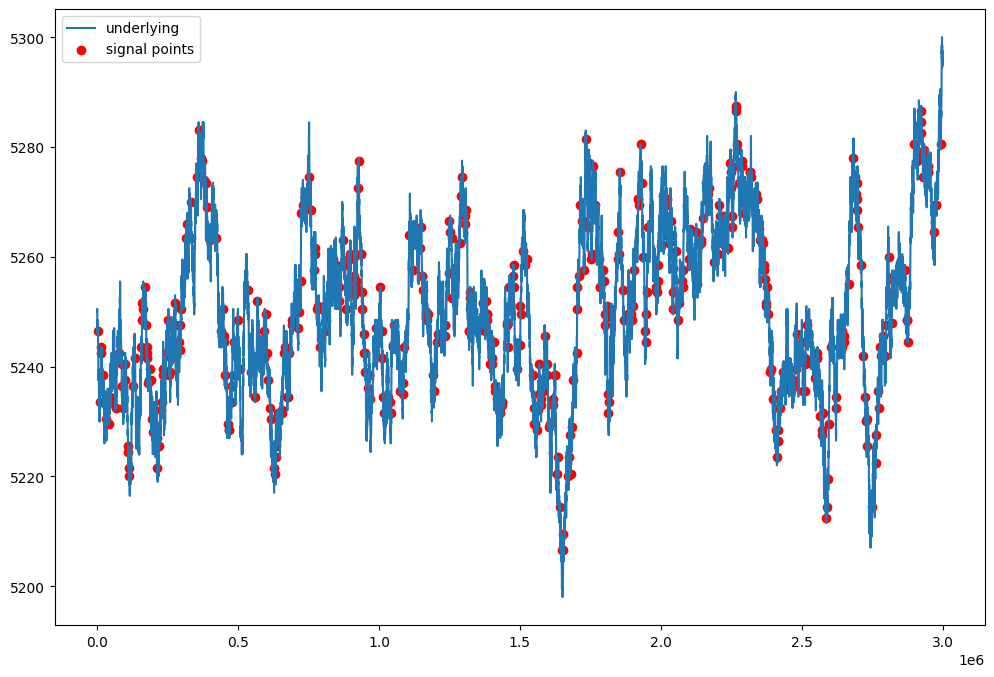

In [206]:
import matplotlib.pyplot as plt

# Filter condition
mask = (vev_4000_prices["bs_spread"] >= 4) | (vev_4000_prices["bs_spread"] <= -4)

filtered = vev_4000_prices[mask]

# Plot bs_spread only when condition is met
plt.figure(figsize=(12, 8))
plt.plot(filtered["global_time"], filtered["bs_spread"], label="bs_spread (|>=4|)")
plt.legend()
plt.show()

# Plot underlying for same timestamps
plt.figure(figsize=(12, 8))
plt.plot(fruit_prices["global_time"], fruit_prices["mid_price"], label="underlying")

# Optional: overlay signal points on underlying
plt.scatter(filtered["global_time"], 
            filtered["s"],  # assuming "s" = underlying price aligned
            color="red", 
            label="signal points")

plt.legend()
plt.show()

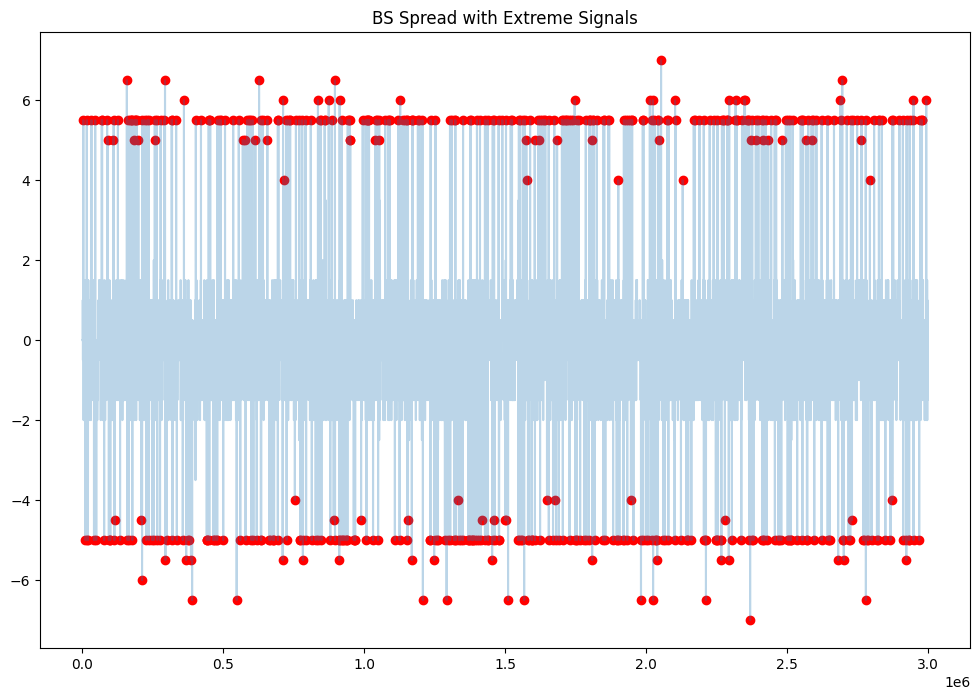

In [207]:
plt.figure(figsize=(12, 8))

# Full bs spread
plt.plot(vev_4000_prices["global_time"], vev_4000_prices["bs_spread"], alpha=0.3)

# Highlight extreme points
plt.scatter(filtered["global_time"], filtered["bs_spread"], color="red")

plt.title("BS Spread with Extreme Signals")
plt.show()

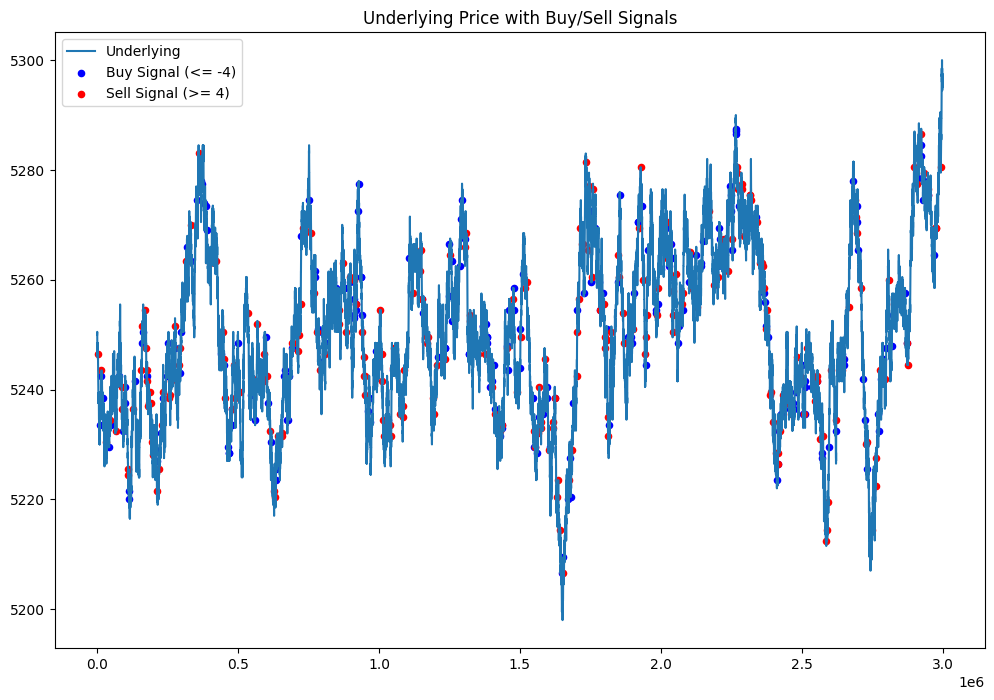

In [208]:
import matplotlib.pyplot as plt

# Buy and sell conditions
buy_mask = vev_4000_prices["bs_spread"] <= -4
sell_mask = vev_4000_prices["bs_spread"] >= 4

# Plot underlying
plt.figure(figsize=(12, 8))
plt.plot(fruit_prices["global_time"], fruit_prices["mid_price"], label="Underlying")

# Plot BUY signals (blue)
plt.scatter(
    vev_4000_prices.loc[buy_mask, "global_time"],
    vev_4000_prices.loc[buy_mask, "s"],   # underlying price aligned
    color="blue",
    label="Buy Signal (<= -4)",
    s=20
)

# Plot SELL signals (red)
plt.scatter(
    vev_4000_prices.loc[sell_mask, "global_time"],
    vev_4000_prices.loc[sell_mask, "s"],
    color="red",
    label="Sell Signal (>= 4)",
    s=20
)

plt.title("Underlying Price with Buy/Sell Signals")
plt.legend()
plt.show()